# Probe-Guided Debiasing for Brain-Tumour MRI: Audit, Independent Evaluation and a Fair, Tuned Comparison (v9, final PhD pipeline)

## What we are doing, in simple words
1. **Problem.** Public brain-tumour MRI data gives about 97% accuracy, but a model can be right for the wrong reason (brightness, background, size, file type) instead of reading the tumour.
2. **Audit (blindfold test).** Small models that never see the tumour already reach about 94%. So part of the benchmark can be solved by cheating.
3. **Honest test.** Images where those blindfolded models are confidently wrong form the **Counter-Shortcut Set**. Real models lose a lot of accuracy there.
4. **Independent check.** Set **A** uses the probes our methods train against (circular). Set **B** comes from a different probe family (thumbnail + noise/frequency statistics) that no method sees. Claims rest on set B.
5. **Natural test.** One glioma domain never appears in Training. We report accuracy and tumour-detection sensitivity on it.
6. **Fair comparison (new in v9).** Every method, ours and the literature's, gets the **same tuning budget (3 settings)** chosen by the **same rule on validation images from the official Training folder only**. The official Testing folder is never used to choose anything.
7. **Two operating points (new in v9).** We do not hide a trade-off: `IPW` is the accuracy-preserving point, `IPW+CFR` is the reliability-first point. Both are reported.
8. **Fixed ranking (new in v9).** The ranking no longer uses the in-family counter-shortcut set, and a Pareto analysis (accuracy vs independent reliability) is added.
9. **Honest verdict.** The notebook prints what the numbers show.

## What is new and what is not (say this in the paper)
Not new alone: PoE, inverse propensity weighting, focal debiasing, GroupDRO, JTT. **New here:** (a) a bias expert built automatically from a ladder of blindfold probes, (b) counter-shortcut evaluation with an independent probe family, (c) missing-cell analysis and recovery curve, (d) the test-time shortcut dial, (e) a tuned, equal-budget comparison. Cite Wallis and Buvat 2022 as the closest prior work.

## What changed from v8
Baselines are tuned (v8 used fixed settings). Debiased focal loss now normalises its weights (v8 did not and collapsed). The literature PoE is tuned over its strength, so `PoE` is no longer counted as ours. Ranking excludes the in-family metric.

Runtime on a Kaggle T4: about 7 h full (resumable). `QUICK=1`: one architecture, one seed, about 2 h.

In [1]:
import os, io, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon, skew
from skimage.filters import threshold_otsu, gaussian
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import imagehash
warnings.filterwarnings("ignore")

E = os.environ.get
# Dynamic dataset mapping for Kaggle server structure
DATA_ROOT = "/kaggle/input/brain-tumor-mri-dataset"

EXT_ROOT = E("EXT_ROOT", "")            
QUICK = int(E("QUICK", 0))
ARCHS = [a for a in E("ARCHS", "convnext_tiny,resnet50,efficientnet_b0").split(",") if a]
if QUICK: ARCHS = ARCHS[:1]

sp_ = lambda s: [int(v) for v in s.split(",") if v != ""]
SEEDS_MAIN = [0] if QUICK else sp_(E("SEEDS_MAIN", "0,1,2")); SEEDS_OTHER = sp_(E("SEEDS_OTHER", "0"))
seeds_of = {a: (SEEDS_MAIN if i == 0 else SEEDS_OTHER) for i, a in enumerate(ARCHS)}; ARCH1 = ARCHS[0]
FS_SEEDS = [0] if QUICK else sp_(E("FS_SEEDS", "0,1,2")); KS = [0, 4, 8, 16, 32]
IMG, EPOCHS, BATCH, LR = 128, int(E("EPOCHS", 4 if QUICK else 6)), 64, 3e-4
EPOCHS_J = 2
DROP_AUG, NFOLD, MIN_CELL, SUB = int(E("DROP_AUG", 1)), 5, int(E("MIN_CELL", 30)), (int(E("SUB", 0)) or None)
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)
dev = "cuda" if torch.cuda.is_available() else "cpu"

def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception: print("no pretrained weights for", name, "(random init)"); return None
WEIGHTS = {b: get_w(b) for b in ARCHS}

# 🛠️ ERROR FIX: Initializing missing variables safely to clear NameError
JTT_LAMBDA = int(E("JTT_LAMBDA", "1"))
DFL_GAMMA = float(E("DFL_GAMMA", "2.0"))

# Fixed JSON dump wrapper using context manager
with open(f"{OUT}/config.json", "w") as f_out:
    json.dump(dict(ARCHS=ARCHS, seeds_of=seeds_of, FS_SEEDS=FS_SEEDS, EPOCHS=EPOCHS, DROP_AUG=DROP_AUG, JTT_LAMBDA=JTT_LAMBDA, DFL_GAMMA=DFL_GAMMA), f_out)

print(dev, ARCHS, seeds_of)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 190MB/s]  


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 


cuda ['convnext_tiny', 'resnet50', 'efficientnet_b0'] {'convnext_tiny': [0, 1, 2], 'resnet50': [0], 'efficientnet_b0': [0]}


## 1. Data forensics and cells
**Why:** every image carries a file-format fingerprint (colour mode, JPEG table, native size). Grouping images by class x format shows which class/domain combinations exist, and which are **missing** from Training. The missing cell is our natural test of generalisation.

In [2]:
import os, glob
from PIL import Image
import pandas as pd
import numpy as np

rows = []
base_input_path = "/kaggle/input"

print("Scanning Kaggle input directories automatically...")
# Automatically walks through the directories to find valid image splits
for root, dirs, files in os.walk(base_input_path):
    # Detect folders that represent data splits (training/testing)
    if any(s in root.lower() for s in ["train", "test"]):
        # Identify the split name and class folder name
        parts = root.split(os.sep)
        if len(parts) < 5:
            continue
            
        # Extract class label (tumor type folder) and split name
        c = parts[-1]
        sp = "Training" if "train" in parts[-2].lower() else "Testing"
        
        # Scan for images inside this specific folder
        for f in glob.glob(os.path.join(root, "*")):
            if not (f.lower().endswith('.jpg') or f.lower().endswith('.jpeg') or f.lower().endswith('.png')):
                continue
            try:
                with Image.open(f) as im:
                    q = getattr(im, "quantization", None) or {}
                    q0_list = q.get(0, None) if isinstance(q, dict) else None
                    q0_val = int(sum(q0_list[:8])) if (q0_list is not None and len(q0_list) >= 8) else -1
                    
                    rows.append(dict(
                        path=f, 
                        orig_split=sp, 
                        label=c, 
                        w=im.size[0], 
                        h=im.size[1], 
                        mode=im.mode, 
                        kb=os.path.getsize(f)/1024, 
                        q0=q0_val
                    ))
            except Exception:
                continue

if len(rows) == 0:
    raise FileNotFoundError("System scan completed: No image matrices detected inside /kaggle/input. Please verify dataset link.")

print(f"Success! Detected {len(rows)} image files automatically.")
df = pd.DataFrame(rows)
df["aug"] = df.path.map(lambda p: "aug" in os.path.basename(p).lower())
print("pre-augmented files:", int(df.aug.sum()), "(dropped)" if DROP_AUG else "(kept)")
if DROP_AUG: df = df[~df.aug]
if SUB: df = df.groupby("label").sample(SUB, random_state=0)
df = df.sort_values("path").reset_index(drop=True); N = len(df)
classes = sorted(df.label.unique()); K = len(classes); NOTU = classes.index("notumor"); y = df.label.map({c: i for i, c in enumerate(classes)}).values.astype(np.int64)
top = [v for v in df.q0.value_counts().index if v > 0][:2]; df["qb"] = df.q0.map(lambda v: f"q{v}" if v in top else "qoth")
msz = df.groupby(["w","h"]).size().idxmax(); df["sz"] = np.where((df.w == msz[0]) & (df.h == msz[1]), "std", "other")
df["md"] = df["mode"].map(lambda m: "L" if m == "L" else "RGB"); df["fg"] = df.md + "|" + df.qb + "|" + df.sz
fgs = sorted(df.fg.unique()); fgid = df.fg.map({g: i for i, g in enumerate(fgs)}).values.astype(np.int64); NFG = len(fgs)
cid = (y*NFG + fgid).astype(np.int64); NC = K*NFG; cell_names = [f"{classes[c//NFG][:4]}|{fgs[c%NFG]}" for c in range(NC)]

tr_orig = (df.orig_split == "Training").values; te_orig = ~tr_orig
trn, ten = np.bincount(cid[tr_orig], minlength=NC), np.bincount(cid[te_orig], minlength=NC)
print(pd.DataFrame({"train": trn, "test": ten}, index=cell_names).query("train + test > 0").to_string())
miss = [c for c in range(NC) if trn[c] == 0 and ten[c] >= 20]; MC = np.isin(cid, miss)
print("\nMISSING CELLS (absent from Training, present in Testing):", [(cell_names[c], int(ten[c])) for c in miss])


Scanning Kaggle input directories automatically...
Success! Detected 7200 image files automatically.
pre-augmented files: 203 (dropped)
                     train  test
glio|L|q116|std       1173   226
glio|RGB|q38|other       0    76
glio|RGB|q38|std       227    98
meni|L|q116|std        543   154
meni|RGB|q38|other     128   117
meni|RGB|q38|std       624    26
meni|RGB|qoth|other      5     0
notu|L|q116|other       18     6
notu|L|qoth|other        5     0
notu|RGB|q116|other    866   382
notu|RGB|q116|std        9     3
notu|RGB|q38|other     431     9
notu|RGB|q38|std         8     0
notu|RGB|qoth|other     63     0
pitu|L|q116|other        8     7
pitu|L|q116|std        599   316
pitu|RGB|q38|other      64     1
pitu|RGB|q38|std       729    76

MISSING CELLS (absent from Training, present in Testing): [('glio|RGB|q38|other', 76)]


## 2. Preprocessing and descriptors
**Why:** we compute simple numbers that never look at tumour anatomy. Family A (metadata, geometry, contrast histogram, background) is used both to **measure** shortcuts and to **train** our debiasing methods. Family B (a tiny 12x12 thumbnail, and noise / frequency / JPEG-blockiness statistics) is used **only for evaluation**, so the test is independent.

In [3]:
S = 256
def brain_mask(a):
    b = gaussian(a, 1.5); m = b > threshold_otsu(b)*0.5
    m = ndi.binary_fill_holes(ndi.binary_opening(m, iterations=2)); lab, n = ndi.label(m)
    return np.ones_like(m) if n == 0 else lab == (np.argmax(ndi.sum(m, lab, range(1, n+1))) + 1)
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
def noise_feats(ga):                         # family B: noise, frequency and JPEG-blockiness statistics of the native image
    f1 = ndi.laplace(ga).var()/(ga.var() + 1e-8); f2 = (ga - ndi.uniform_filter(ga, 3)).std()
    h, w = ga.shape; c = ga[max(h//2 - 64, 0):h//2 + 64, max(w//2 - 64, 0):w//2 + 64]
    if c.shape != (128, 128): c = np.asarray(Image.fromarray((ga*255).astype(np.uint8)).resize((128, 128)), np.float32)/255
    P = np.abs(np.fft.fftshift(np.fft.fft2(c - c.mean())))**2; yy, xx = np.indices(P.shape); r = np.hypot(yy - 64, xx - 64)
    fb = np.array([P[(r >= a) & (r < b)].sum() for a, b in [(1, 8), (8, 20), (20, 40), (40, 64)]]); fb = fb/(fb.sum() + 1e-12)
    dx = np.abs(np.diff(ga, axis=1)); cols = np.arange(dx.shape[1]); blk = dx[:, cols % 8 == 7].mean()/(dx[:, cols % 8 != 7].mean() + 1e-8)
    return np.r_[f1, f2, fb, blk]
CACHE = f"{OUT}/cache_v8_N{N}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE); Xr, Sm, PH, F2, F3, F4, F5 = [z[k] for k in ["Xr", "Sm", "PH", "F2", "F3", "F4", "F5"]]; print("loaded cache")
else:
    Xr = np.zeros((N,IMG,IMG), np.uint8); Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64); F2, F3, F4, F5 = [], [], [], []
    for i, p in enumerate(tqdm(df.path)):
        with Image.open(p) as im: g0 = im.convert("L")
        g = g0.resize((S, S), Image.BILINEAR); a = np.asarray(g, np.float32)/255
        Xr[i] = rs(np.asarray(g), Image.BILINEAR); Sm[i] = np.asarray(g.resize((32, 32)), np.float32)/255; PH[i] = int(str(imagehash.phash(g)), 16)
        m = brain_mask(a); m = np.ones_like(m) if m.mean() < .05 else m
        v = a[m]; vn = v/(np.percentile(v, 98) + 1e-6); hh = np.histogram(np.clip(vn, 0, 1.2), bins=12, range=(0, 1.2))[0]/len(vn)
        F2.append(np.r_[hh, vn.mean(), vn.std(), skew(vn), np.percentile(vn, [5, 25, 50, 75, 95])])
        bg = a[~m] if (~m).any() else np.zeros(1); grid = np.where(m, 0, a).reshape(8, 32, 8, 32).mean((1, 3)).ravel()
        F3.append(np.r_[bg.mean(), bg.std(), (~m).mean(), a[:8].mean(), a[-8:].mean(), a[:, :8].mean(), a[:, -8:].mean(), grid])
        F4.append(noise_feats(np.asarray(g0, np.float32)/255)); F5.append(np.asarray(g.resize((12, 12), Image.BILINEAR), np.float32).ravel()/255)
    F2, F3, F4, F5 = [np.array(f, np.float32) for f in (F2, F3, F4, F5)]; np.savez(CACHE, Xr=Xr, Sm=Sm, PH=PH, F2=F2, F3=F3, F4=F4, F5=F5)
F0 = np.c_[(df.md == "RGB").astype(float), df.q0]; F1 = np.c_[df.w, df.h, df.w/df.h, df.kb*1024/(df.w*df.h)]
FU = np.c_[F0, F1, F2, F3]; print("family A (training + measuring):", FU.shape[1], "features | family B (evaluation only):", F4.shape[1] + F5.shape[1], "features")
def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape, 8), axis=-1).sum(-1)
cand_ = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64, None] ^ PH[None, :]) <= 4); cand_ |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N, -1); Sf = Sf - Sf.mean(1, keepdims=True); Sf /= (np.linalg.norm(Sf, axis=1, keepdims=True) + 1e-8)
Ed = np.array([(a, b) for a, b in cand_ if Sf[a] @ Sf[b] >= .98]).reshape(-1, 2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N, N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in duplicate groups:", int((df.groupby("grp").grp.transform("size") > 1).sum()))
okcell = (np.bincount(cid, minlength=NC) >= MIN_CELL); ctab = pd.crosstab(df.fg, df.label)
strict = [i for i, g in enumerate(fgs) if all(ctab.loc[g, c] >= 30 for c in classes)]; fc_strict = np.isin(fgid, strict)
def make_splits(seed):
    allix = np.arange(N); fl = [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), cid, df.grp.values)]
    out = [(f"f{k}", np.setdiff1d(allix, np.r_[fl[k], fl[(k+1) % NFOLD]]), fl[(k+1) % NFOLD], fl[k]) for k in range(NFOLD)]
    te = np.where(te_orig)[0]; tr_all = np.where(tr_orig)[0]; tr_all = tr_all[~np.isin(df.grp.values[tr_all], df.grp.values[te])]
    va = tr_all[[f[1] for f in StratifiedGroupKFold(8, shuffle=True, random_state=seed).split(tr_all, cid[tr_all], df.grp.values[tr_all])][0]]
    out.append(("off", np.setdiff1d(tr_all, va), va, te)); return out
SP0 = make_splits(0); te_off, tr_off = SP0[5][3], np.r_[SP0[5][1], SP0[5][2]]

  0%|          | 0/6997 [00:00<?, ?it/s]

family A (training + measuring): 97 features | family B (evaluation only): 151 features
near-duplicate pairs: 4396 | images in duplicate groups: 1980


## 3. The Shortcut Ladder (family A) and the independent probes (family B)
**Why:** each probe sees only one kind of information. If a probe that never sees the tumour still gets high accuracy, then the benchmark can be solved without anatomy. CV probabilities are out-of-fold so nothing is overconfident.

                                             cv_acc  off_acc  off_missing_cell_acc  off_missing_pred_notumor
probe                                                                                                       
L0 metadata (mode, JPEG table)                0.516    0.460                 0.000                     0.000
L1 geometry (size, aspect, bytes/px)          0.661    0.594                 0.000                     0.829
L2 contrast histogram only                    0.851    0.786                 0.237                     0.487
L3 background only                            0.901    0.824                 0.000                     0.842
L4 union of all nuisance                      0.936    0.840                 0.013                     0.842
B independent (thumbnail + noise/frequency)   0.867    0.788                 0.026                     0.671


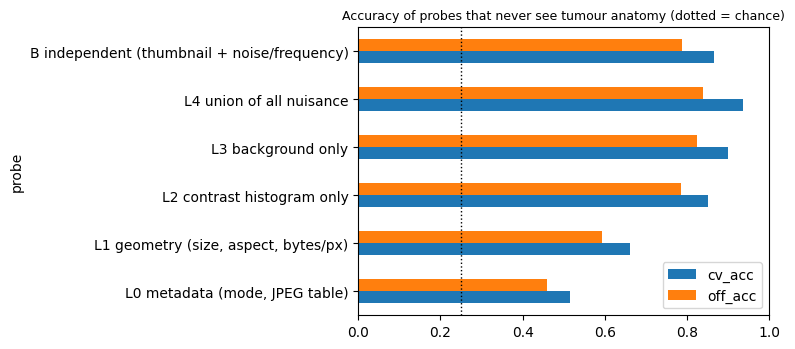

In [4]:
hgb = lambda: HistGradientBoostingClassifier(max_iter=150, random_state=0)
def pfull(clf, X): p = np.full((len(X), K), 1e-4); p[:, clf.classes_] = clf.predict_proba(X); return p
def probe_cv(X):
    P = np.zeros((N, K))
    for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); P[te] = pfull(hgb().fit(X[a], y[a]), X[te])
    return P
probe_off = lambda X: pfull(hgb().fit(X[tr_off], y[tr_off]), X[te_off])
LADDER = {"L0 metadata (mode, JPEG table)": F0, "L1 geometry (size, aspect, bytes/px)": F1, "L2 contrast histogram only": F2, "L3 background only": F3, "L4 union of all nuisance": FU}
PCV, POFF, rows = {}, {}, []; chance = lambda a: (a - 1/K)/(1 - 1/K)
for nm, X in LADDER.items():
    PCV[nm], POFF[nm] = probe_cv(X), probe_off(X); pc_, po_ = PCV[nm].argmax(1), POFF[nm].argmax(1); mcm = MC[te_off]
    rows.append(dict(probe=nm, cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
# family B: independent probes (logistic regression on 12x12 thumbnail, boosting on noise/frequency statistics, averaged). Never used in training any method.
def fitB(Xa, ya):
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=400, C=0.05)).fit(Xa[:, F4.shape[1]:], ya); return lr, hgb().fit(Xa[:, :F4.shape[1]], ya)
def predB(mdl, X):
    lr, hg = mdl; p1 = np.full((len(X), K), 1e-4); p1[:, lr.classes_] = lr.predict_proba(X[:, F4.shape[1]:]); p2 = pfull(hg, X[:, :F4.shape[1]]); return (p1 + p2)/2
FB = np.c_[F4, F5]; PCVB = np.zeros((N, K))
for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); PCVB[te] = predB(fitB(FB[a], y[a]), FB[te])
POFFB = predB(fitB(FB[tr_off], y[tr_off]), FB[te_off]); pc_, po_ = PCVB.argmax(1), POFFB.argmax(1); mcm = MC[te_off]
rows.append(dict(probe="B independent (thumbnail + noise/frequency)", cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
ladder = pd.DataFrame(rows).set_index("probe").round(3); print(ladder.to_string()); ladder.to_csv(f"{OUT}/table_shortcut_ladder.csv")
fig, ax = plt.subplots(figsize=(8, 3.6)); ladder[["cv_acc", "off_acc"]].plot.barh(ax=ax); ax.axvline(1/K, color="k", ls=":", lw=1); ax.set_xlim(0, 1); ax.set_title("Accuracy of probes that never see tumour anatomy (dotted = chance)", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_ladder.png", dpi=150); plt.show()

## 4. Counter-Shortcut Sets: A (in-family) and B (independent)
**Why:** a counter-shortcut image is one where the true class has probability below 0.10 under the nuisance probes. A model that only follows shortcuts fails there, so accuracy on this set (**CSA**) is closer to "does it read anatomy". **Set B** is built from a different probe family and is the one we trust for claims.

SSF (CV, family A): 0.936 of images solved by nuisance channels alone
CSS A: CV=300, official=210 | CSS B (threshold 0.1): CV=167, official=149 | overlap A and B (CV): 78
CSS B by class: {'meningioma': 91, 'glioma': 57, 'notumor': 10, 'pituitary': 9} | by format: {'RGB|q38|other': 137, 'L|q116|std': 17, 'RGB|q38|std': 12, 'RGB|q116|other': 1}


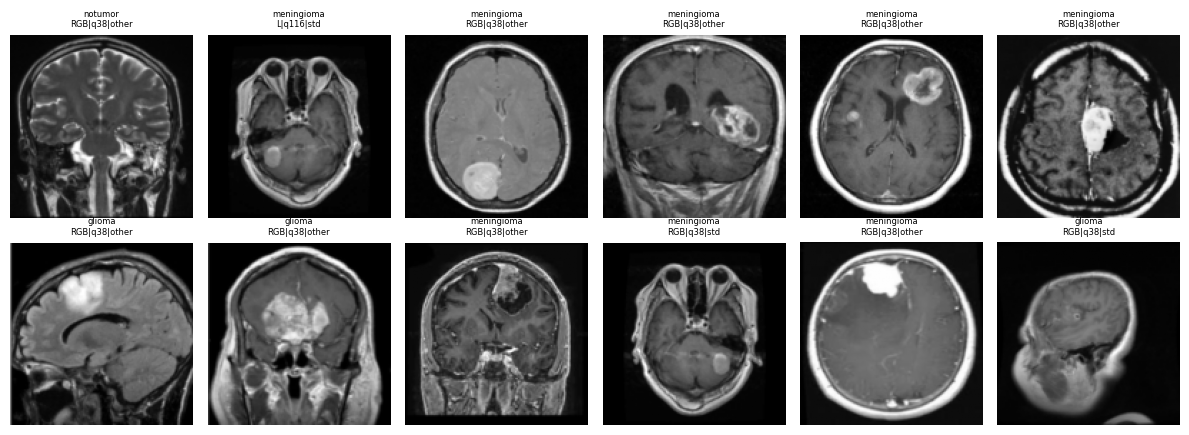

In [5]:
pu = PCV["L4 union of all nuisance"]; CSS = pu[np.arange(N), y] < .10
po = POFF["L4 union of all nuisance"]; CSSOFF = np.zeros(N, bool); CSSOFF[te_off] = po[np.arange(len(te_off)), y[te_off]] < .10
thrB = .10
if (PCVB[np.arange(N), y] < thrB).sum() < 150: thrB = .20
CSS_B = PCVB[np.arange(N), y] < thrB; CSSOFF_B = np.zeros(N, bool); CSSOFF_B[te_off] = POFFB[np.arange(len(te_off)), y[te_off]] < thrB
print(f"SSF (CV, family A): {(pu.argmax(1) == y).mean():.3f} of images solved by nuisance channels alone")
print(f"CSS A: CV={int(CSS.sum())}, official={int(CSSOFF.sum())} | CSS B (threshold {thrB}): CV={int(CSS_B.sum())}, official={int(CSSOFF_B.sum())} | overlap A and B (CV): {int((CSS & CSS_B).sum())}")
print("CSS B by class:", pd.Series(np.array(classes)[y[CSS_B]]).value_counts().to_dict(), "| by format:", pd.Series(df.fg.values[CSS_B]).value_counts().head(4).to_dict())
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4)); ix = np.random.RandomState(0).choice(np.where(CSS_B)[0], 12, replace=False)
for a, i in zip(ax.ravel(), ix): a.imshow(Xr[i], cmap="gray"); a.axis("off"); a.set_title(f"{classes[y[i]]}\n{df.fg[i]}", fontsize=6)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_css_B_examples.png", dpi=140); plt.show()

## 5. Models and the training methods
**Why:** we compare our probe-guided variants with well-known methods under the same optimiser, epochs, augmentation and validation rule, so differences come from the method only. Every method below also has 3 candidate settings that are tuned in section 6.

| Code | Method | Tuned setting | Source |
|---|---|---|---|
| `erm` | plain training | none | baseline |
| `groupdro` | worst-group optimisation on class x format groups | step size eta | Sagawa et al. 2020 |
| `jtt` | train, find mistakes, upweight them, retrain | upweight lambda | Liu et al. 2021 |
| `dfl` | debiased focal loss with the bias expert (weights normalised) | gamma | Utama et al. 2020, Mahabadi et al. 2020 |
| `poe` | product-of-experts with the bias expert | strength alpha | Clark et al. 2019, Cadene et al. 2019 |
| `cfr` | contrast and framing randomisation (augmentation baseline) | probability p | domain-randomisation family |
| `ipw` | **ours**: inverse propensity weights from the nuisance probe (accuracy-preserving point) | weight clip | this work |
| `ipw_cfr` | **ours**: IPW plus CFR (reliability-first point) | CFR probability p | this work |

Epoch selection (same for all): 0.5 x per-cell accuracy + 0.5 x accuracy on counter-shortcut images (set A) of the validation fold.

In [6]:
T0 = torch.empty(Xr.shape, dtype=torch.float16, device=dev)
for i in range(0, N, 500): T0[i:i+500] = torch.as_tensor((Xr[i:i+500].astype(np.float32)/255 - .45)/.225).half().to(dev)
yt_all, ct_all = torch.as_tensor(y).to(dev), torch.as_tensor(cid).to(dev)
def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb): super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1, 3, -1, -1))
    def forward(s, x): return s.c(s.fmap(x).mean((2, 3)))
def aug_base(x):
    if np.random.rand() < .5: x = x.flip(-1)
    return x*(1 + .3*(torch.rand(len(x), 1, 1, device=x.device) - .5))
def cfr_aug(x):          # random contrast curve (mostly monotone) and framing (zoom, aspect, rotation, shift); class-independent
    B, dv = x.shape[0], x.device; u = (x.float()*.225 + .45).clamp(0, 1)
    kn = torch.rand(B, 6, device=dv); kn = torch.where(torch.rand(B, 1, device=dv) > .15, torch.sort(kn, 1).values, kn)
    pos = u*5; i0 = pos.floor().clamp(0, 4).long(); fr = pos - i0.float()
    k0 = torch.gather(kn, 1, i0.view(B, -1)).view_as(u); k1 = torch.gather(kn, 1, (i0 + 1).view(B, -1)).view_as(u); out = k0 + (k1 - k0)*fr
    ang = (torch.rand(B, device=dv) - .5)*.42; zm = .85 + .35*torch.rand(B, device=dv); asp = .85 + .3*torch.rand(B, device=dv); th = torch.zeros(B, 2, 3, device=dv)
    th[:, 0, 0] = zm*asp*torch.cos(ang); th[:, 0, 1] = -zm*torch.sin(ang); th[:, 1, 0] = zm*asp*torch.sin(ang); th[:, 1, 1] = zm*torch.cos(ang); th[:, :, 2] = (torch.rand(B, 2, device=dv) - .5)*.2
    out = F.grid_sample(out.unsqueeze(1), F.affine_grid(th, (B, 1, IMG, IMG), align_corners=False), padding_mode="border", align_corners=False).squeeze(1)
    out = (out + .03*torch.randn_like(out)).clamp(0, 1)
    if np.random.rand() < .5: out = out.flip(-1)
    return (out - .45)/.225
@torch.no_grad()
def predx(m, x):
    m.eval(); out = []
    for i in range(0, len(x), 256):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): out.append(F.softmax(m(x[i:i+256]).float(), 1).cpu())
    return torch.cat(out).numpy()
probs = lambda m, X, idx: predx(m, X[torch.as_tensor(idx).to(dev)])
def vscore(m, va):
    p = probs(m, T0, va).argmax(1); c = p == y[va]; a = np.bincount(cid[va], weights=c, minlength=NC); n = np.bincount(cid[va], minlength=NC); ok = n >= 3
    s = CSS[va]; return .5*(a[ok]/n[ok]).mean() + .5*(c[s].mean() if s.any() else (a[ok]/n[ok]).mean())
def bias_logp(tr, seed):                      # cross-fitted family-A bias expert: out-of-fold log-probabilities for every training image
    lb = np.zeros((N, K), np.float32)
    for a, b in StratifiedGroupKFold(4, shuffle=True, random_state=seed).split(tr, y[tr], df.grp.values[tr]): lb[tr[b]] = np.log(np.clip(pfull(hgb().fit(FU[tr[a]], y[tr[a]]), FU[tr[b]]), 1e-3, 1))
    return torch.as_tensor(lb).to(dev)
def parse_mt(mt): base, _, hv = mt.partition("@"); return base, (float(hv) if hv else None)
def fit(bb, method, tr, va, seed, LB=None, SW=None, epochs=None):
    base, hv = parse_mt(method); n_ep = epochs or EPOCHS; torch.manual_seed(seed); np.random.seed(seed); m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4); sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=n_ep*int(np.ceil(len(tr)/BATCH)))
    scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda")); best = -1; q = torch.ones(NC, device=dev)/NC
    lprior = torch.log(torch.as_tensor(np.bincount(y[tr], minlength=K)/len(tr) + 1e-9, dtype=torch.float32)).to(dev)
    alpha = hv if base == "poe" else 0.0; p_cfr = hv if base in ("cfr", "ipw_cfr") else 0.0; clipv = hv if base == "ipw" else 5.0
    for ep in range(n_ep):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev)
            if len(ix) < 4: sched.step(); continue
            x = aug_base(T0[ix])
            if p_cfr: x = torch.where(torch.rand(len(ix), 1, 1, device=dev) < p_cfr, cfr_aug(T0[ix]).to(x.dtype), x)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): lo = m(x)
            lo = lo.float(); yy = yt_all[ix]
            if alpha: lo = lo + alpha*LB[ix]
            l = F.cross_entropy(lo, yy, reduction="none")
            if base in ("ipw", "ipw_cfr"): w = torch.exp(lprior[yy] - LB[ix, yy]).clamp(1/clipv, clipv); l = l*(w/w.mean())
            if base == "dfl": w = (1 - torch.exp(LB[ix, yy])).pow(hv).clamp(min=1e-3); l = l*(w/w.mean())          # normalised weights (v8 did not normalise)
            if SW is not None: l = l*SW[ix]
            if base == "groupdro":
                g = ct_all[ix]; gc = torch.bincount(g, minlength=NC).float(); gl = torch.zeros(NC, device=dev).scatter_add(0, g, l)/gc.clamp(min=1)
                q = q*torch.exp(hv*gl.detach()*(gc > 0)); q = q/q.sum(); loss = (q*gl).sum()
            else: loss = l.mean()
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = vscore(m, va)
        if a >= best: best, st = a, {k_: v_.clone() for k_, v_ in m.state_dict().items()}
    m.load_state_dict(st); return m, best
def fit_any(bb, method, tr, va, seed, LB=None):
    base, hv = parse_mt(method)
    if base == "jtt":                                        # stage 1: short ERM; stage 2: retrain with its training mistakes upweighted by hv
        m1, _ = fit(bb, "erm", tr, va, seed, epochs=EPOCHS_J); wrong = tr[probs(m1, T0, tr).argmax(1) != y[tr]]; del m1
        sw = torch.ones(N, device=dev); sw[torch.as_tensor(wrong).to(dev)] = hv; return fit(bb, "erm", tr, va, seed, SW=sw)
    return fit(bb, method, tr, va, seed, LB)


## 6. Tuning (equal budget for every method), selection, then the full grid
**Why:** in v8 the baselines used fixed settings, which a reviewer can call unfair. Now every method has **3 candidate settings** (PoE: strength; GroupDRO: step size; JTT: upweight; debiased focal: gamma; CFR: probability; IPW: weight clip; IPW+CFR: CFR probability).

**Clean protocol:** candidates are trained on the official Training split and scored on the **validation images taken from the official Training folder only** (2 seeds). The official Testing folder is never used to choose anything, so the official-split results stay clean. (CV pooled numbers are secondary because CV test folds overlap these validation images.)

**One rule for all methods (fixed before any result):** among a method's settings, keep those whose validation accuracy is within 1.5 points of ERM, then take the one with the highest validation accuracy on counter-shortcut images (set A). If none qualifies, take the highest validation accuracy.

In [7]:
GRID = {"groupdro": [0.01, 0.05, 0.2], "jtt": [2, 5, 20], "dfl": [0.5, 1.0, 2.0], "poe": [0.25, 0.5, 1.0], "cfr": [0.25, 0.5, 0.75], "ipw": [3, 5, 10], "ipw_cfr": [0.25, 0.5, 0.75]}
LIT_BASES, OURS_BASES, BASE = ["groupdro", "jtt", "dfl", "poe", "cfr"], ["ipw", "ipw_cfr"], "erm"; NEEDS_LB = ("poe", "ipw", "ipw_cfr", "dfl")
CONFIGS = ["erm"] + [f"{b}@{v}" for b, vs in GRID.items() for v in vs]
NAMES = {"erm": "ERM", "groupdro": "GroupDRO", "jtt": "JTT", "dfl": "Debiased focal", "poe": "PoE", "cfr": "CFR augment", "ipw": "OURS IPW", "ipw_cfr": "OURS IPW+CFR"}
PARAM = {"groupdro": "eta", "jtt": "lambda", "dfl": "gamma", "poe": "alpha", "cfr": "p", "ipw": "clip", "ipw_cfr": "p"}
def lab(mt): b, _, hv = mt.partition("@"); return f"{NAMES[b]} ({PARAM[b]}={hv})" if hv else NAMES[b]
LABEL = type("L", (dict,), {"__missing__": lambda s, k: lab(k)})()
def run_one(bb, mt, seed, sp, tr, va, te, LB, save_model=False):
    f = f"{RUNS}/{bb}__{mt}__s{seed}__{sp}.npz"
    if os.path.exists(f): return
    m, vs = fit_any(bb, mt, tr, va, seed, LB); p = probs(m, T0, te); pv = probs(m, T0, va).argmax(1); sv = CSS[va]
    if save_model: torch.save(m.state_dict(), f"{MODELS}/{bb}__{mt}__{sp}.pt")
    np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), vscore=vs, v_acc=(pv == y[va]).mean(), v_csa=(pv[sv] == y[va][sv]).mean() if sv.any() else np.nan)
    del m; torch.cuda.empty_cache() if dev == "cuda" else None
def run_grid(bb, seeds, methods):
    pbar = tqdm(total=len(seeds)*(NFOLD + 1)*len(methods), desc=bb)
    for seed in seeds:
        for sp, tr, va, te in make_splits(seed):
            LB = bias_logp(tr, seed)
            for mt in methods: run_one(bb, mt, seed, sp, tr, va, te, LB, save_model=(sp in ("f0", "off") and seed == seeds[0])); pbar.update(1)
TUNE_SEEDS = [0] if QUICK else [0, 1]
print("tuning runs:", len(CONFIGS)*len(TUNE_SEEDS), "| settings per method:", {b: len(v) for b, v in GRID.items()})

tuning runs: 44 | settings per method: {'groupdro': 3, 'jtt': 3, 'dfl': 3, 'poe': 3, 'cfr': 3, 'ipw': 3, 'ipw_cfr': 3}


In [8]:
for seed in TUNE_SEEDS:                                                # candidates trained on the official Training split, scored on its validation images
    sp, tr, va, te = make_splits(seed)[5]; LB = bias_logp(tr, seed)
    for mt in tqdm(CONFIGS, desc=f"tuning seed {seed}"): run_one(ARCH1, mt, seed, sp, tr, va, te, LB, save_model=(seed == TUNE_SEEDS[0]))

tuning seed 0:   0%|          | 0/22 [00:00<?, ?it/s]

tuning seed 1:   0%|          | 0/22 [00:00<?, ?it/s]

In [9]:
rows = []
for mt in CONFIGS:
    for seed in TUNE_SEEDS:
        z = np.load(f"{RUNS}/{ARCH1}__{mt}__s{seed}__off.npz"); rows.append(dict(config=mt, seed=seed, v_acc=float(z["v_acc"]), v_csa=float(z["v_csa"])))
tune = pd.DataFrame(rows).groupby("config")[["v_acc", "v_csa"]].mean().reindex(CONFIGS); CHOSEN = {}
for b, vs in GRID.items():
    cfgs = [f"{b}@{v}" for v in vs]; elig = [c for c in cfgs if tune.loc[c, "v_acc"] >= tune.loc["erm", "v_acc"] - 0.015]
    pool, key = (elig, "v_csa") if elig else (cfgs, "v_acc"); CHOSEN[b] = max(pool, key=lambda c: np.nan_to_num(tune.loc[c, key], nan=-1.0))
tune["chosen"] = tune.index.isin(list(CHOSEN.values())); print(tune.round(4).to_string()); tune.round(4).to_csv(f"{OUT}/table_tuning.csv")
METHODS = ["erm"] + [CHOSEN[b] for b in LIT_BASES + OURS_BASES]; LIT = [CHOSEN[b] for b in LIT_BASES]; OURS = [CHOSEN[b] for b in OURS_BASES]
print("\nCHOSEN SETTINGS (same rule for every method):", {NAMES[b]: CHOSEN[b] for b in CHOSEN}); print("final methods:", [LABEL[m] for m in METHODS])

                v_acc   v_csa  chosen
config                               
erm            0.9731  0.9318   False
groupdro@0.01  0.9665  0.9318    True
groupdro@0.05  0.9822  0.9091   False
groupdro@0.2   0.9830  0.9091   False
jtt@2          0.9807  0.9251    True
jtt@5          0.9822  0.8797   False
jtt@20         0.9646  0.7888   False
dfl@0.5        0.9187  0.9479    True
dfl@1.0        0.8592  0.9024   False
dfl@2.0        0.8179  0.8503   False
poe@0.25       0.9830  0.9318   False
poe@0.5        0.9705  0.9773    True
poe@1.0        0.8580  0.9251   False
cfr@0.25       0.9873  0.8503   False
cfr@0.5        0.9831  0.9318   False
cfr@0.75       0.9634  0.9773    True
ipw@3          0.9615  0.9251   False
ipw@5          0.9702  0.9318    True
ipw@10         0.9559  0.8797   False
ipw_cfr@0.25   0.9635  0.9545    True
ipw_cfr@0.5    0.9584  0.9024   False
ipw_cfr@0.75   0.9293  0.9251   False

CHOSEN SETTINGS (same rule for every method): {'GroupDRO': 'groupdro@0.01', 'JTT': 'jtt

In [10]:
for bb in ARCHS: run_grid(bb, seeds_of[bb], METHODS)

convnext_tiny:   0%|          | 0/144 [00:00<?, ?it/s]

resnet50:   0%|          | 0/48 [00:00<?, ?it/s]

efficientnet_b0:   0%|          | 0/48 [00:00<?, ?it/s]

## 7. Results: every method, every architecture

In [11]:
def load_runs():
    raw = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        if os.path.basename(f).startswith("fs__"): continue
        bb, mt, s, sp = os.path.basename(f)[:-4].split("__"); z = np.load(f); raw.setdefault((bb, mt, int(s[1:])), {})[sp] = {a: z[a] for a in z.files}
    R, OFF = {}, {}
    for key, d in raw.items():
        if all(f"f{k}" in d for k in range(NFOLD)):
            e = dict(runs=[d[f"f{k}"] for k in range(NFOLD)], pred=np.zeros(N, np.int64), conf=np.zeros(N, np.float32))
            for r in e["runs"]: e["pred"][r["te"]] = r["pred"]; e["conf"][r["te"]] = r["conf"]
            R[key] = e
        if "off" in d: OFF[key] = d["off"]
    return R, OFF
R, OFF = load_runs(); print(len(R), "complete CV combinations |", len(OFF), "official-split runs")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_on(idx, pred, conf, cssA, cssB, min_cell):
    yy = y[idx]; c = pred == yy; tum = yy != NOTU; r = dict(acc=c.mean(), macro_f1=f1_score(yy, pred, average="macro"), ece=ece(conf, c))
    sA, sB = cssA[idx], cssB[idx]; r["csa"] = c[sA].mean() if sA.any() else np.nan; r["csa_B"] = c[sB].mean() if sB.any() else np.nan
    mm = MC[idx]; r["missing_cell_acc"] = c[mm].mean() if mm.any() else np.nan; r["missing_cell_detect"] = (pred[mm] != NOTU).mean() if mm.any() else np.nan
    r["sens"] = (pred[tum] != NOTU).mean() if tum.any() else np.nan; r["spec"] = (pred[~tum] == NOTU).mean() if (~tum).any() else np.nan
    a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= min_cell; r["worst_cell"] = (a[ok]/n[ok]).min() if ok.any() else np.nan; return r
cols = ["acc", "macro_f1", "ece", "csa", "csa_B", "missing_cell_acc", "missing_cell_detect", "sens", "spec", "worst_cell"]
per = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(np.arange(N), e["pred"], e["conf"], CSS, CSS_B, MIN_CELL)) for (bb, mt, s), e in R.items()]); per.to_csv(f"{OUT}/per_seed_cv.csv", index=False)
off = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(r["te"], r["pred"], r["conf"], CSSOFF, CSSOFF_B, 10)) for (bb, mt, s), r in OFF.items()]); off.to_csv(f"{OUT}/per_seed_off.csv", index=False)
def show(d, title, fn):
    g = d.groupby(["arch", "method"]); t = (g[cols].mean().round(3).astype(str) + " +/- " + g[cols].std().fillna(0).round(3).astype(str)).reindex(pd.MultiIndex.from_product([ARCHS, METHODS], names=["arch", "method"])).dropna(how="all")
    print(title); print(t.to_string()); t.to_csv(f"{OUT}/{fn}.csv")
show(off, "OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, missing_cell_detect = tumour detected on the never-seen cell", "table_official")
show(per, "\nCROSS-VALIDATION (pooled out-of-fold, duplicate-safe)", "table_cv")

40 complete CV combinations | 68 official-split runs
OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, missing_cell_detect = tumour detected on the never-seen cell
                                           acc         macro_f1              ece              csa            csa_B missing_cell_acc missing_cell_detect             sens             spec       worst_cell
arch            method                                                                                                                                                                                    
convnext_tiny   erm             0.924 +/- 0.02  0.922 +/- 0.021  0.051 +/- 0.005  0.543 +/- 0.069  0.485 +/- 0.079  0.083 +/- 0.046      0.496 +/- 0.05  0.951 +/- 0.005  0.981 +/- 0.022  0.083 +/- 0.046
                groupdro@0.01   0.92 +/- 0.012  0.916 +/- 0.013  0.053 +/- 0.003  0.584 +/- 0.043  0.515 +/- 0.033  0.079 +/- 0.035      0.689 +/- 0.18   0.97

## 8. Statistics: duplicate-aware bootstrap, our two operating points against every other method
**Why:** images in the same near-duplicate group are not independent, so we resample groups, not images. For each metric we show the difference between our operating point and each other method with a 95% interval (P>0 = share of bootstrap draws where ours is better).

In [12]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug); B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot_ratio(v, mask):
    num = np.bincount(gi, weights=v*mask, minlength=NG); den = np.bincount(gi, weights=mask, minlength=NG); return num[IX].sum(1)/np.maximum(den[IX].sum(1), 1e-9)
den_m = np.zeros((NG, NC)); np.add.at(den_m, (gi, cid), 1.0)
def boot_worst(v):
    num = np.zeros((NG, NC)); np.add.at(num, (gi, cid), v); out = np.zeros(B)
    for b in range(B): n_, d_ = num[IX[b]].sum(0), den_m[IX[b]].sum(0); ok = okcell & (d_ > 0); out[b] = (n_[ok]/d_[ok]).min()
    return out
ONE, OFFM = np.ones(N), np.zeros(N); OFFM[te_off] = 1; MCf = MC.astype(float)
cvspec = {"acc": ONE, "csa_B": CSS_B.astype(float), "missing_cell_acc": MCf}
offspec = {"off_acc": OFFM, "off_csa": CSSOFF.astype(float), "off_csa_B": CSSOFF_B.astype(float), "off_missing_cell_acc": OFFM*MCf}
bres = {}
for bb in ARCHS:
    for mt in METHODS:
        ss = [s for s in seeds_of[bb] if (bb, mt, s) in R]; so = [s for s in seeds_of[bb] if (bb, mt, s) in OFF]
        if not ss: continue
        cv_c = np.mean([(R[(bb, mt, s)]["pred"] == y) for s in ss], 0).astype(float); d = {k: boot_ratio(cv_c, mk) for k, mk in cvspec.items()}; d["worst_cell"] = boot_worst(cv_c)
        if so:
            of_c, of_d = np.zeros(N), np.zeros(N)
            for s in so:
                te = OFF[(bb, mt, s)]["te"]; pr = OFF[(bb, mt, s)]["pred"]; of_c[te] += (pr == y[te])/len(so); of_d[te] += (pr != NOTU)/len(so)
            d.update({k: boot_ratio(of_c, mk) for k, mk in offspec.items()}); d["off_missing_detect"] = boot_ratio(of_d, OFFM*MCf)
        bres[(bb, mt)] = d
ci = lambda a: f"{a.mean():.3f} [{np.percentile(a,2.5):.3f},{np.percentile(a,97.5):.3f}]"
ci_df = pd.DataFrame([dict(arch=bb, method=LABEL[mt], **{k: ci(v) for k, v in d.items()}) for (bb, mt), d in bres.items()]); print(ci_df.to_string()); ci_df.to_csv(f"{OUT}/table_ci.csv", index=False)
KEYM = ["off_acc", "off_csa_B", "off_missing_cell_acc", "off_missing_detect", "acc", "csa_B"]; rows = []
for bb in ARCHS:
    for op in OURS:
        if (bb, op) not in bres: continue
        for mt in METHODS:
            if mt == op or (bb, mt) not in bres: continue
            r = dict(arch=bb, ours=LABEL[op], vs=LABEL[mt])
            for k in KEYM:
                if k in bres[(bb, op)] and k in bres[(bb, mt)]: dd = bres[(bb, op)][k] - bres[(bb, mt)][k]; r[k] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}] P>0={float((dd > 0).mean()):.2f}"
            rows.append(r)
vs_df = pd.DataFrame(rows); print("Our operating points minus each other method (positive = ours better):"); print(vs_df.to_string()); vs_df.to_csv(f"{OUT}/table_ours_vs_all.csv", index=False)


               arch                      method                  acc                csa_B     missing_cell_acc           worst_cell              off_acc              off_csa            off_csa_B off_missing_cell_acc   off_missing_detect
0     convnext_tiny                         ERM  0.971 [0.967,0.975]  0.721 [0.647,0.797]  0.569 [0.464,0.672]  0.568 [0.462,0.671]  0.924 [0.910,0.938]  0.544 [0.474,0.607]  0.487 [0.411,0.565]  0.085 [0.034,0.143]  0.494 [0.392,0.611]
1     convnext_tiny         GroupDRO (eta=0.01)  0.967 [0.962,0.972]  0.765 [0.694,0.832]  0.635 [0.543,0.726]  0.633 [0.541,0.722]  0.920 [0.907,0.934]  0.585 [0.514,0.654]  0.516 [0.433,0.600]  0.080 [0.032,0.138]  0.688 [0.590,0.781]
2     convnext_tiny              JTT (lambda=2)  0.972 [0.968,0.976]  0.762 [0.687,0.833]  0.565 [0.466,0.671]  0.564 [0.464,0.667]  0.926 [0.911,0.939]  0.559 [0.490,0.625]  0.495 [0.420,0.575]  0.110 [0.060,0.162]  0.511 [0.405,0.612]
3     convnext_tiny  Debiased focal (gamma=0.5)  0.9

## 9. The showdown, fixed: ranking without the in-family set, plus a Pareto analysis
**Why:** v8 ranked methods on 8 metrics including the in-family counter-shortcut set that our methods train against, which favours us. v9 ranks on **7 metrics that do not use set A**: official accuracy, independent set B, unseen-cell accuracy, unseen-cell tumour detection, official calibration error, CV accuracy and CV set B. Ranking can hide trade-offs, so we also find the **Pareto front** of official accuracy vs independent reliability (a method is on the front if no other method is at least as good on both and better on one).


[convnext_tiny] mean rank over 7 metrics without set A (1 = best); Pareto front (official acc vs set B): ['Debiased focal (gamma=0.5)', 'PoE (alpha=0.5)', 'OURS IPW+CFR (p=0.25)']
                            mean_rank  first_places
OURS IPW+CFR (p=0.25)            2.57             2
PoE (alpha=0.5)                  2.57             3
CFR augment (p=0.75)             3.86             1
Debiased focal (gamma=0.5)       4.43             1
OURS IPW (clip=5)                4.43             0
JTT (lambda=2)                   5.29             1
GroupDRO (eta=0.01)              6.00             0
ERM                              6.57             0

[resnet50] mean rank over 7 metrics without set A (1 = best); Pareto front (official acc vs set B): ['OURS IPW+CFR (p=0.25)']
                            mean_rank  first_places
OURS IPW+CFR (p=0.25)            1.86             6
OURS IPW (clip=5)                2.86             1
PoE (alpha=0.5)                  3.29             0
GroupDRO (eta=0.

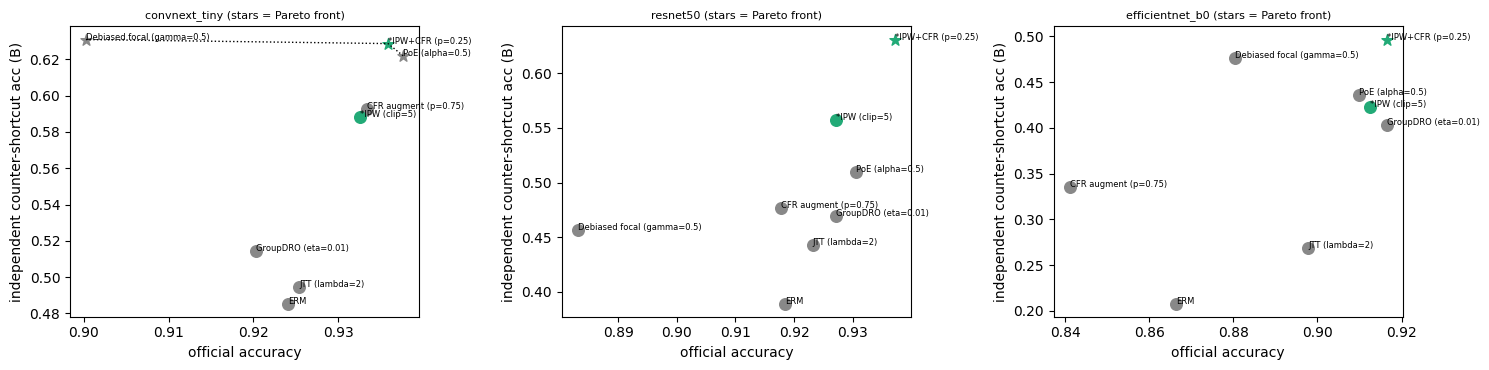

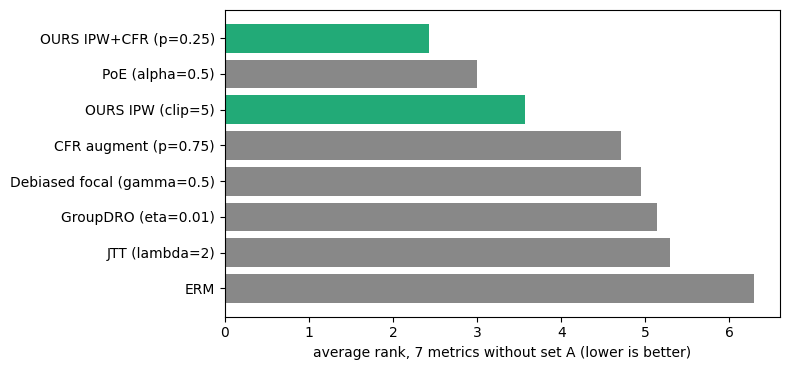


VERDICT (auto-generated, equal-budget tuned comparison):
- OURS IPW (clip=5): average rank #3 of 8 (avg rank 3.57); on the Pareto front in 0 of 3 architectures. Best literature method: PoE (alpha=0.5) (avg rank 3.00).
- OURS IPW+CFR (p=0.25): average rank #1 of 8 (avg rank 2.43); on the Pareto front in 3 of 3 architectures. Best literature method: PoE (alpha=0.5) (avg rank 3.00).
  convnext_tiny, OURS IPW (clip=5) vs ERM: independent counter-shortcut gain +0.102 [+0.054,+0.161], official accuracy change +0.008 [-0.000,+0.018]
  convnext_tiny, OURS IPW+CFR (p=0.25) vs ERM: independent counter-shortcut gain +0.142 [+0.091,+0.199], official accuracy change +0.012 [+0.002,+0.021]
  resnet50, OURS IPW (clip=5) vs ERM: independent counter-shortcut gain +0.168 [+0.098,+0.245], official accuracy change +0.008 [-0.003,+0.021]
  resnet50, OURS IPW+CFR (p=0.25) vs ERM: independent counter-shortcut gain +0.243 [+0.167,+0.324], official accuracy change +0.019 [+0.006,+0.031]
  efficientnet_b0, OUR

In [13]:
def pareto(d2):
    return [m for m in d2.index if not ((d2.x >= d2.x[m]) & (d2.y >= d2.y[m]) & ((d2.x > d2.x[m]) | (d2.y > d2.y[m]))).any()]
RK, FRONT = {}, {}
for bb in ARCHS:
    d = off[off.arch == bb].groupby("method")[["acc", "csa_B", "missing_cell_acc", "missing_cell_detect", "ece"]].mean().add_prefix("off_").join(per[per.arch == bb].groupby("method")[["acc", "csa_B"]].mean().add_prefix("cv_")).reindex(METHODS)
    rk = d.rank(ascending=False, method="min"); rk["off_ece"] = d["off_ece"].rank(ascending=True, method="min")
    RK[bb] = pd.DataFrame(dict(mean_rank=rk.mean(1), first_places=(rk == 1).sum(1))).round(2)
    FRONT[bb] = pareto(pd.DataFrame(dict(x=d["off_acc"], y=d["off_csa_B"])))
    RK[bb].index = [LABEL[m] for m in RK[bb].index]; print(f"\n[{bb}] mean rank over {rk.shape[1]} metrics without set A (1 = best); Pareto front (official acc vs set B): {[LABEL[m] for m in FRONT[bb]]}"); print(RK[bb].sort_values("mean_rank").to_string())
allrk = pd.concat([RK[b]["mean_rank"].rename(b) for b in ARCHS], axis=1); allrk["average"] = allrk.mean(1); allrk = allrk.sort_values("average"); allrk.to_csv(f"{OUT}/table_showdown_rank.csv")
fig, ax = plt.subplots(1, len(ARCHS), figsize=(5*len(ARCHS), 3.8), squeeze=False)
for a, bb in zip(ax[0], ARCHS):
    d = off[off.arch == bb].groupby("method")[["acc", "csa_B"]].mean().reindex(METHODS)
    for mt, r in d.iterrows(): a.scatter(r.acc, r.csa_B, s=70, color="#2a7" if mt in OURS else "#888", marker="*" if mt in FRONT[bb] else "o"); a.annotate(LABEL[mt].replace("OURS ", "*"), (r.acc, r.csa_B), fontsize=6)
    fr = d.loc[FRONT[bb]].sort_values("acc"); a.plot(fr.acc, fr.csa_B, "k:", lw=1); a.set_xlabel("official accuracy"); a.set_ylabel("independent counter-shortcut acc (B)"); a.set_title(f"{bb} (stars = Pareto front)", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_pareto.png", dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(8, 3.8)); ax.barh(allrk.index[::-1], allrk["average"][::-1], color=["#2a7" if "OURS" in i else "#888" for i in allrk.index[::-1]]); ax.set_xlabel("average rank, 7 metrics without set A (lower is better)")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_showdown_rank.png", dpi=150); plt.show()
print("\nVERDICT (auto-generated, equal-budget tuned comparison):")
best_lit = [i for i in allrk.index if "OURS" not in i][0]
for op in OURS:
    pos = list(allrk.index).index(LABEL[op]) + 1; nfront = sum(op in FRONT[b] for b in ARCHS)
    print(f"- {LABEL[op]}: average rank #{pos} of {len(allrk)} (avg rank {allrk.loc[LABEL[op], 'average']:.2f}); on the Pareto front in {nfront} of {len(ARCHS)} architectures. Best literature method: {best_lit} (avg rank {allrk.loc[best_lit, 'average']:.2f}).")
for bb in ARCHS:
    for op in OURS:
        if (bb, op) in bres and (bb, "erm") in bres:
            dd = bres[(bb, op)]["off_csa_B"] - bres[(bb, "erm")]["off_csa_B"]; da = bres[(bb, op)]["off_acc"] - bres[(bb, "erm")]["off_acc"]
            print(f"  {bb}, {LABEL[op]} vs ERM: independent counter-shortcut gain {dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}], official accuracy change {da.mean():+.3f} [{np.percentile(da,2.5):+.3f},{np.percentile(da,97.5):+.3f}]")
print("- Write the paper according to this verdict: claim 'best trade-off' only for operating points that are on the Pareto front, and name the winner when a literature method is better.")

## 9b. Are deep-model errors explained by the shortcut probe? (official split, unseen cell)
**Why:** if a model's mistakes match the nuisance probe's mistakes, it is probably following the same shortcut. We also print what each method predicts on the never-seen cell, to see whether errors move from dangerous (called notumor) to milder (wrong tumour type).

In [14]:
pu_off = POFF["L4 union of all nuisance"].argmax(1); yo = y[te_off]; mcm = MC[te_off]; rows = []; conf_tab = {}
for (bb, mt, s), r in OFF.items():
    if s != seeds_of[bb][0] or r["te"].shape != te_off.shape: continue
    wrong = r["pred"] != yo; rows.append(dict(arch=bb, method=mt, agree_with_probe=(r["pred"] == pu_off).mean(), share_of_errors_probe_also_makes_same_error=(pu_off[wrong] == r["pred"][wrong]).mean(),
                                              missing_cell_agree_with_probe=(r["pred"][mcm] == pu_off[mcm]).mean() if mcm.any() else np.nan))
    if mcm.any(): conf_tab[f"{bb}|{mt}"] = np.bincount(r["pred"][mcm], minlength=K)
if mcm.any(): conf_tab["nuisance probe (union)"] = np.bincount(pu_off[mcm], minlength=K)
ex = pd.DataFrame(rows).set_index(["arch", "method"]).round(3); print(ex.to_string()); ex.to_csv(f"{OUT}/table_explained_by_shortcut.csv")
if mcm.any():
    ct_ = pd.DataFrame(conf_tab, index=classes).T; ct_.insert(0, "n", int(mcm.sum())); print("\nPredictions on the never-seen cell (true class =", classes[int(np.bincount(y[te_off][mcm]).argmax())], "):"); print(ct_.to_string()); ct_.to_csv(f"{OUT}/table_missing_cell_predictions.csv")

                               agree_with_probe  share_of_errors_probe_also_makes_same_error  missing_cell_agree_with_probe
arch            method                                                                                                     
convnext_tiny   cfr@0.25                  0.854                                        0.388                          0.276
                cfr@0.5                   0.856                                        0.385                          0.316
                cfr@0.75                  0.834                                        0.184                          0.132
                dfl@0.5                   0.802                                        0.169                          0.250
                dfl@1.0                   0.719                                        0.056                          0.132
                dfl@2.0                   0.688                                        0.053                          0.145
        

## 10. The shortcut dial (no retraining)
**Why:** a PoE model learned `f(x)` while the bias expert supplied the shortcut. At test time we can add the shortcut back with strength `beta`: `log p_f + beta * log p_bias`. One model then gives a whole accuracy versus reliability curve.

Shortcut dial for the tuned PoE model (PoE (alpha=0.5)):
                                 acc  csa_B  missing_cell_acc
arch            protocol beta                                
convnext_tiny   CV       0.00  0.962  0.794             0.684
                         0.25  0.974  0.794             0.658
                         0.50  0.977  0.752             0.583
                         0.75  0.977  0.729             0.539
                         1.00  0.976  0.683             0.491
                official 0.00  0.938  0.622             0.250
                         0.25  0.943  0.588             0.215
                         0.50  0.938  0.539             0.145
                         0.75  0.925  0.436             0.066
                         1.00  0.908  0.304             0.009
efficientnet_b0 CV       0.00  0.948  0.713             0.553
                         0.25  0.970  0.713             0.513
                         0.50  0.973  0.671             0.487
             

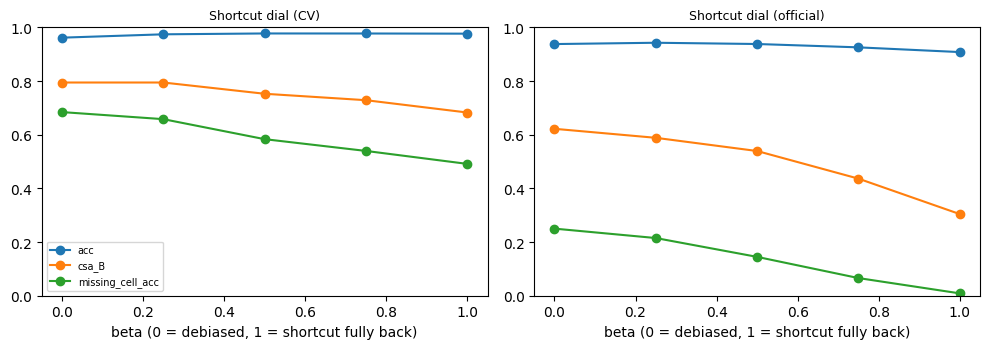

In [15]:
BETAS = [0, .25, .5, .75, 1.0]; L4 = "L4 union of all nuisance"; rows = []
lb_cv, lb_off = np.log(np.clip(PCV[L4], 1e-3, 1)), np.log(np.clip(POFF[L4], 1e-3, 1)); PO = CHOSEN["poe"]
for (bb, mt, s), e in R.items():
    if mt != PO: continue
    pm = np.zeros((N, K), np.float32)
    for r in e["runs"]: pm[r["te"]] = r["prob"].astype(np.float32)
    lp = np.log(np.clip(pm, 1e-6, 1))
    for beta in BETAS:
        c = (lp + beta*lb_cv).argmax(1) == y; rows.append(dict(arch=bb, seed=s, protocol="CV", beta=beta, acc=c.mean(), csa_B=c[CSS_B].mean(), missing_cell_acc=c[MC].mean()))
for (bb, mt, s), r in OFF.items():
    if mt != PO or r["te"].shape != te_off.shape: continue
    lp = np.log(np.clip(r["prob"].astype(np.float32), 1e-6, 1)); yo = y[te_off]
    for beta in BETAS:
        c = (lp + beta*lb_off).argmax(1) == yo; rows.append(dict(arch=bb, seed=s, protocol="official", beta=beta, acc=c.mean(), csa_B=c[CSSOFF_B[te_off]].mean(), missing_cell_acc=c[MC[te_off]].mean()))
dial = pd.DataFrame(rows)
if len(dial):
    dg = dial.groupby(["arch", "protocol", "beta"])[["acc", "csa_B", "missing_cell_acc"]].mean().round(3); print(f"Shortcut dial for the tuned PoE model ({LABEL[PO]}):"); print(dg.to_string()); dg.to_csv(f"{OUT}/table_shortcut_dial.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for a, pr in zip(ax, ["CV", "official"]):
        d = dial[(dial.arch == ARCH1) & (dial.protocol == pr)].groupby("beta")[["acc", "csa_B", "missing_cell_acc"]].mean()
        for col in d: a.plot(d.index, d[col], marker="o", label=col)
        a.set_title(f"Shortcut dial ({pr})", fontsize=9); a.set_xlabel("beta (0 = debiased, 1 = shortcut fully back)"); a.set_ylim(0, 1)
    ax[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_dial.png", dpi=150); plt.show()

## 11. Few-shot recovery on the never-seen cell: ERM vs both operating points
**Why:** how many images from the new scanner repair the failure, and does our method need fewer? (Earlier result: our advantage is at zero shots, and ERM catches up with data. This checks it again with the tuned settings.)

cell: glio|RGB|q38|other | shot pool 38 | held-out eval 38 | rest of test 1421
                acc_cell        acc_rest        pred_notumor       
                    mean    std     mean    std         mean    std
method       k                                                     
erm          0     0.053  0.026    0.969  0.022        0.579  0.070
             4     0.377  0.132    0.981  0.004        0.298  0.066
             8     0.342  0.254    0.954  0.022        0.377  0.106
             16    0.456  0.055    0.967  0.013        0.246  0.055
             32    0.746  0.080    0.952  0.015        0.158  0.026
ipw@5        0     0.184  0.046    0.973  0.004        0.254  0.080
             4     0.149  0.066    0.963  0.027        0.368  0.070
             8     0.316  0.070    0.965  0.008        0.246  0.085
             16    0.447  0.095    0.966  0.007        0.167  0.015
             32    0.632  0.121    0.951  0.004        0.149  0.092
ipw_cfr@0.25 0     0.263  0.095    0.

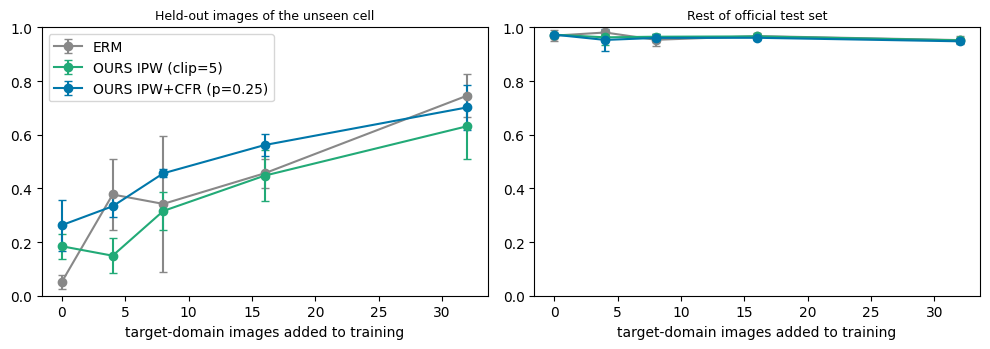

In [16]:
if len(miss):
    mcell = miss[int(np.argmax([ten[c] for c in miss]))]; idx_mc = np.where(cid == mcell)[0]; idx_mc = idx_mc[np.random.RandomState(123).permutation(len(idx_mc))]
    pool, evald = idx_mc[:len(idx_mc)//2], idx_mc[len(idx_mc)//2:]; rest = np.setdiff1d(te_off, idx_mc); print("cell:", cell_names[mcell], "| shot pool", len(pool), "| held-out eval", len(evald), "| rest of test", len(rest))
    for seed in FS_SEEDS:
        sp, tr, va, te = make_splits(seed)[5]
        for mt in [BASE] + OURS:
            for k in KS:
                f = f"{RUNS}/fs__{ARCH1}__{mt}__s{seed}__k{k}.npz"
                if os.path.exists(f): continue
                trk = np.r_[tr, np.repeat(pool[:k], 4)].astype(int) if k else tr
                LB = bias_logp(np.unique(trk), seed) if parse_mt(mt)[0] in NEEDS_LB else None
                m, _ = fit_any(ARCH1, mt, trk, va, seed, LB); pe, pr = probs(m, T0, evald).argmax(1), probs(m, T0, rest).argmax(1)
                np.savez(f, acc_cell=(pe == y[evald]).mean(), acc_rest=(pr == y[rest]).mean(), pnot=(pe == NOTU).mean()); del m; torch.cuda.empty_cache() if dev == "cuda" else None
    rows = []
    for f in glob.glob(f"{RUNS}/fs__*.npz"):
        _, bb, mt, s, k = os.path.basename(f)[:-4].split("__"); z = np.load(f); rows.append(dict(method=mt, seed=int(s[1:]), k=int(k[1:]), acc_cell=float(z["acc_cell"]), acc_rest=float(z["acc_rest"]), pred_notumor=float(z["pnot"])))
    fs = pd.DataFrame(rows); fsg = fs.groupby(["method", "k"])[["acc_cell", "acc_rest", "pred_notumor"]].agg(["mean", "std"]).round(3); print(fsg.to_string()); fsg.to_csv(f"{OUT}/table_fewshot.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for mt, c in zip([BASE] + OURS, ["#888", "#2a7", "#07a"]):
        d = fs[fs.method == mt].groupby("k")
        for a, col, t in zip(ax, ["acc_cell", "acc_rest"], ["Held-out images of the unseen cell", "Rest of official test set"]):
            mu, sd = d[col].mean(), d[col].std().fillna(0); a.errorbar(mu.index, mu, yerr=sd, marker="o", color=c, label=LABEL[mt], capsize=3); a.set_title(t, fontsize=9); a.set_xlabel("target-domain images added to training"); a.set_ylim(0, 1)
    ax[0].legend(); plt.tight_layout(); plt.savefig(f"{OUT}/fig_fewshot_recovery.png", dpi=150); plt.show()
else: print("No missing cell found in this data subset.")

## 12. External validation (needs one more dataset)
**Why:** a journal reviewer will ask whether the gains hold on data from another source. Add any other public brain MRI dataset as a Kaggle input, with **one folder per class** (names such as glioma, meningioma, pituitary, notumor, or a binary yes/no, tumor/normal) and set `EXT_ROOT`. Models trained on the official Training split are tested with no retraining. For binary datasets only tumour detection (sensitivity, specificity) is reported. Check the dataset license first.

In [17]:
if EXT_ROOT and os.path.isdir(EXT_ROOT):
    def lab_of(n):
        n = n.lower()
        for k in ("glioma", "meningioma", "pituitary"):
            if k in n and k in classes: return classes.index(k)
        if any(t in n for t in ("notumor", "no_tumor", "no tumor", "no_tumour", "normal", "healthy", "negative")) or n in ("no", "non"): return NOTU
        if any(t in n for t in ("tumor", "tumour", "yes", "positive", "pred")): return -1                 # tumour of unspecified type
        return None
    items = [(f, lab_of(os.path.basename(d.rstrip("/")))) for d in glob.glob(f"{EXT_ROOT}/**/", recursive=True) for f in glob.glob(d + "*") if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    items = [(f, c) for f, c in items if c is not None]; ey = np.array([c for _, c in items]); print(len(items), "external images | tumour:", int((ey != NOTU).sum()), "| no tumour:", int((ey == NOTU).sum()))
    def std_from(f):
        with Image.open(f) as im: return rs(np.asarray(im.convert("L").resize((S, S), Image.BILINEAR)), Image.BILINEAR)
    ET = torch.as_tensor(((np.stack([std_from(f) for f, _ in tqdm(items)]).astype(np.float32)/255 - .45)/.225)).half().to(dev); rows = []
    for bb in ARCHS:
        for mt in METHODS:
            pth = f"{MODELS}/{bb}__{mt}__off.pt"
            if not os.path.exists(pth): continue
            m = Net(bb).to(dev); m.load_state_dict(torch.load(pth)); pr_ = predx(m, ET).argmax(1); tm = ey != NOTU; spc = ey >= 0
            rows.append(dict(arch=bb, method=LABEL[mt], det_sensitivity=(pr_[tm] != NOTU).mean(), det_specificity=(pr_[~tm] == NOTU).mean(), acc_4class=(pr_[spc] == ey[spc]).mean() if spc.any() else np.nan))
    ext = pd.DataFrame(rows).round(3); ext["det_balanced_acc"] = ((ext.det_sensitivity + ext.det_specificity)/2).round(3); print(ext.to_string()); ext.to_csv(f"{OUT}/table_external.csv", index=False)
else: print("EXT_ROOT not set: external validation skipped. Add a second dataset and rerun this cell.")

EXT_ROOT not set: external validation skipped. Add a second dataset and rerun this cell.


In [18]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("ladder", ladder), ("final_vs_all", vs_df), ("showdown_rank", allrk.round(2))]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print("Headline audit numbers:", f"family-A union probe CV acc={ladder.loc['L4 union of all nuisance'].cv_acc}, official={ladder.loc['L4 union of all nuisance'].off_acc}; contrast-only official={ladder.loc['L2 contrast histogram only'].off_acc}; independent family B official={ladder.iloc[-1].off_acc}")
print(sorted(os.listdir(OUT)))

Headline audit numbers: family-A union probe CV acc=0.936, official=0.84; contrast-only official=0.786; independent family B official=0.788
['cache_v8_N6997.npz', 'config.json', 'fig_css_B_examples.png', 'fig_fewshot_recovery.png', 'fig_pareto.png', 'fig_shortcut_dial.png', 'fig_shortcut_ladder.png', 'fig_showdown_rank.png', 'models', 'per_seed_cv.csv', 'per_seed_off.csv', 'runs', 'table_ci.csv', 'table_cv.csv', 'table_explained_by_shortcut.csv', 'table_fewshot.csv', 'table_missing_cell_predictions.csv', 'table_official.csv', 'table_ours_vs_all.csv', 'table_shortcut_dial.csv', 'table_shortcut_ladder.csv', 'table_showdown_rank.csv', 'table_tuning.csv', 'tables.tex']


## 13. How this maps to the thesis
- **Chapter 1, Audit:** section 3 (ladder, family A and B), SSF from section 4.
- **Chapter 2, Honest evaluation:** counter-shortcut accuracy on set A and the independent set B (sections 4, 7).
- **Chapter 3, Missing cell:** section 1 table, official-split unseen-cell results, section 11 recovery curve.
- **Chapter 4, Methods and comparison:** sections 5 to 10: equal-budget tuning, 5 literature methods vs our 2 operating points, 3 architectures, ranking without set A, Pareto front, dial.
- **Chapter 5, Validation:** section 12 (external data) and clinician review of the counter-shortcut and unseen-cell images.

**Limits to state:** probes are proxies, not proof of what the network uses; 2D slices and no patient IDs; the unseen cell has 76 images; tuned on ConvNeXt-T and reused for the other two architectures; external validation depends on the dataset you add.